# WEEX Eolienne - Phase 1 (TD1-TD2)

## Objectif
Construire une analyse exploitable pour le **rapport** et la **presentation orale** :
- modeliser la puissance electrique en fonction du vent ;
- identifier les conditions d'utilisation optimale de l'eolienne ;
- fournir des indicateurs robustes et des visualisations defendables.

## Hypotheses de travail (phase 1)
- Le fichier `donnees.txt` correspond a une campagne de mesure certifiee.
- La direction est exprimee en degres meteorologiques (0-359).
- Le statut (`Statut`) indique si la machine etait disponible (1) ou arretee (0).
- L'air est considere sec ; la densite est corrigee avec pression et temperature mesurees.

## Plan du notebook
1. Chargement et controle qualite des donnees.
2. Statistiques de vent et de production.
3. Construction d'une courbe de puissance experimentale robuste.
4. Identification des zones de fonctionnement optimales (vitesse + direction).
5. Indicateurs de synthese directement reutilisables dans un rendu.

In [1]:
# Bibliotheques standards pour une analyse scientifique reproductible.
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Confort d'affichage.
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# Chargement robuste du fichier brut (separateur variable, espaces, tabulations).
path = "donnees.txt"

raw = pd.read_csv(path, sep=r"\s+", engine="python")
raw.columns = [c.strip() for c in raw.columns]

rename_map = {
    "Vitess_Vent_[m/s]": "wind_speed",
    "Dir_Vent_[deg]": "wind_dir",
    "Pelec[w]": "power_w",
    "Patm[Pa]": "patm_pa",
    "Temp[degC]": "temp_c",
    "Statut": "status",
}

df = raw.rename(columns=rename_map).copy()

# Conversions explicites pour maitriser les types.
for col in ["wind_speed", "wind_dir", "power_w", "patm_pa", "temp_c"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["status"] = pd.to_numeric(df["status"], errors="coerce").fillna(0).astype(int)

# Features physiques utiles pour l'analyse.
# Densite de l'air par loi des gaz parfaits: rho = p / (R * T).
R_AIR = 287.05  # J/(kg.K)
df["temp_k"] = df["temp_c"] + 273.15
df["rho_air"] = df["patm_pa"] / (R_AIR * df["temp_k"])

# Energies specifiques utiles pour les comparaisons relatives.
df["v3"] = df["wind_speed"] ** 3

print("Dimensions:", df.shape)
print("Colonnes:", list(df.columns))
df.head()

Dimensions: (19918, 9)
Colonnes: ['wind_speed', 'wind_dir', 'power_w', 'patm_pa', 'temp_c', 'status', 'temp_k', 'rho_air', 'v3']


,wind_speed,wind_dir,power_w,patm_pa,temp_c,status,temp_k,rho_air,v3
0,4.400,221,35857,100782,-1.200,1,271.950,1.291,85.184
1,8.100,325,228431,101925,2.500,1,275.650,1.288,531.441
2,1.600,14,0,102126,7.500,1,280.650,1.268,4.096
3,1.300,235,0,100436,-1.300,0,271.850,1.287,2.197
4,3.000,80,0,100317,14.400,1,287.550,1.215,27.000


In [3]:
# Controle qualite des donnees et diagnostic de disponibilite.
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": 100 * df.isna().mean(),
})

print("--- Controle qualite ---")
display(quality)

n = len(df)
availability = (df["status"] == 1).mean()
zero_power_ratio = (df["power_w"] <= 0).mean()

print(f"Disponibilite machine (status=1): {availability:.2%}")
print(f"Part de mesures a puissance nulle: {zero_power_ratio:.2%}")

# Sous-ensemble principal: machine en fonctionnement.
df_on = df[df["status"] == 1].copy()
print("Mesures retenues pour la modelisation principale:", len(df_on))

--- Controle qualite ---


,dtype,missing,missing_%
wind_speed,float64,0,0.000
wind_dir,int64,0,0.000
power_w,int64,0,0.000
patm_pa,int64,0,0.000
temp_c,float64,0,0.000
status,int64,0,0.000
temp_k,float64,0,0.000
rho_air,float64,0,0.000
v3,float64,0,0.000


Disponibilite machine (status=1): 99.10%
Part de mesures a puissance nulle: 18.10%
Mesures retenues pour la modelisation principale: 19738


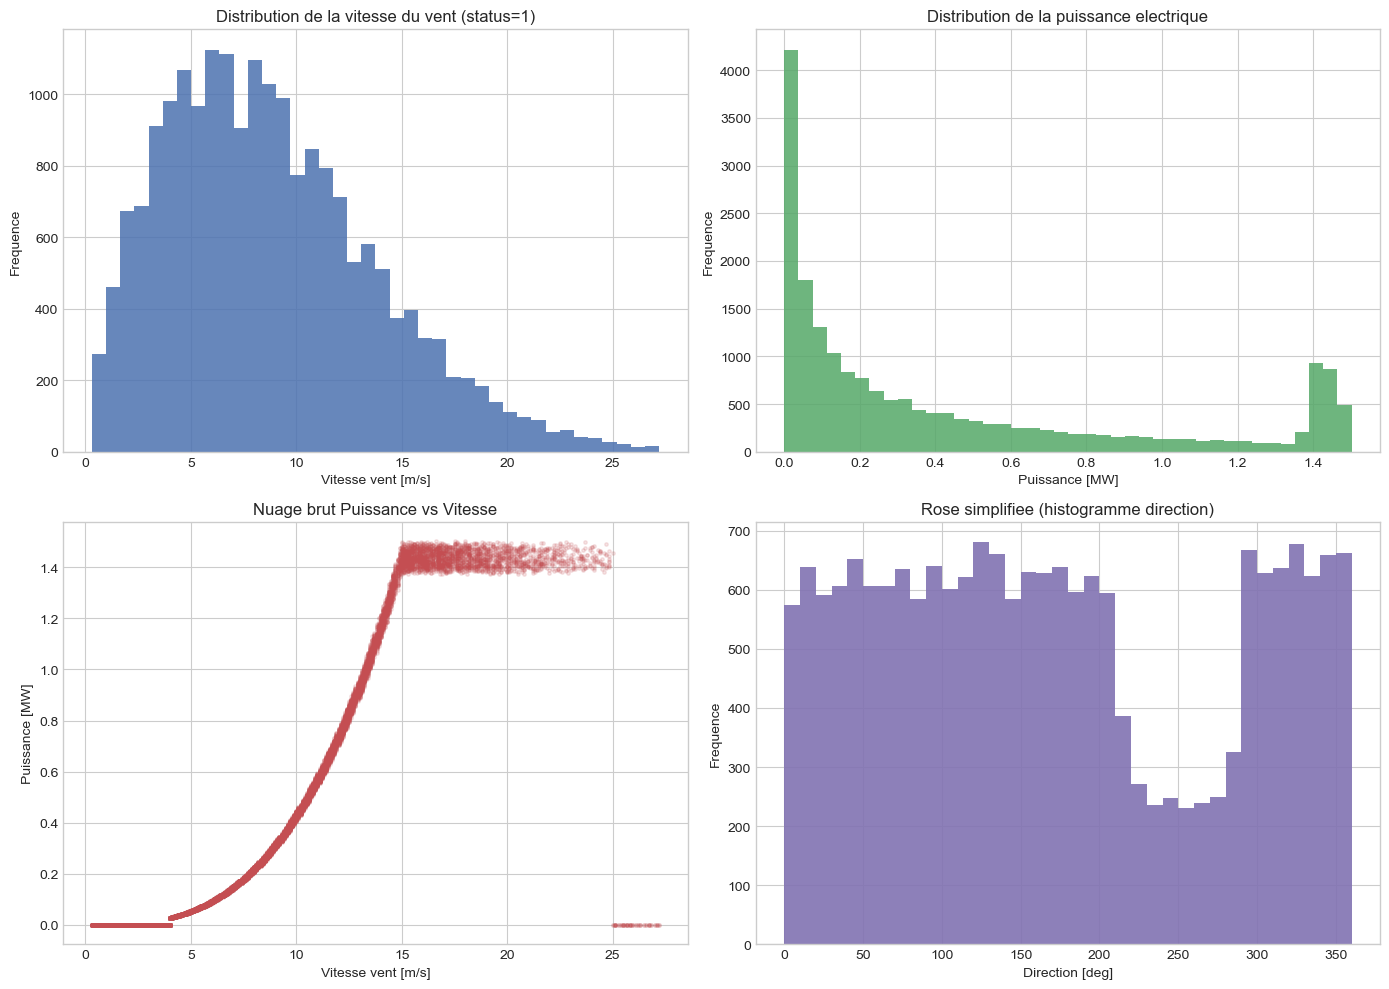

In [4]:
# Vue globale: distributions clefs pour vent, puissance et direction.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df_on["wind_speed"], bins=40, color="#4C72B0", alpha=0.85)
axes[0, 0].set_title("Distribution de la vitesse du vent (status=1)")
axes[0, 0].set_xlabel("Vitesse vent [m/s]")
axes[0, 0].set_ylabel("Frequence")

axes[0, 1].hist(df_on["power_w"] / 1e6, bins=40, color="#55A868", alpha=0.85)
axes[0, 1].set_title("Distribution de la puissance electrique")
axes[0, 1].set_xlabel("Puissance [MW]")
axes[0, 1].set_ylabel("Frequence")

axes[1, 0].scatter(
    df_on["wind_speed"],
    df_on["power_w"] / 1e6,
    s=6,
    alpha=0.15,
    color="#C44E52"
)
axes[1, 0].set_title("Nuage brut Puissance vs Vitesse")
axes[1, 0].set_xlabel("Vitesse vent [m/s]")
axes[1, 0].set_ylabel("Puissance [MW]")

axes[1, 1].hist(df_on["wind_dir"], bins=36, color="#8172B2", alpha=0.9)
axes[1, 1].set_title("Rose simplifiee (histogramme direction)")
axes[1, 1].set_xlabel("Direction [deg]")
axes[1, 1].set_ylabel("Frequence")

plt.tight_layout()
plt.show()

Puissance nominale estimee (mediane): 1.438 MW
Vitesse de demarrage estimee: 4.20 m/s
Vitesse de regime nominal estimee: 15.19 m/s


,n,v_mean,p_med,p_q10,p_q90
0,68,0.346,0.000,0.000,0.000
1,205,0.742,0.000,0.000,0.000
2,314,1.213,0.000,0.000,0.000
3,418,1.710,0.000,0.000,0.000
4,518,2.206,0.000,0.000,0.000
5,572,2.710,0.000,0.000,0.000
6,647,3.205,0.000,0.000,0.000
7,684,3.704,0.000,0.000,0.000
8,728,4.203,"31,604.000",0.000,"36,367.700"
9,753,4.706,"44,359.000","38,740.400","50,242.400"


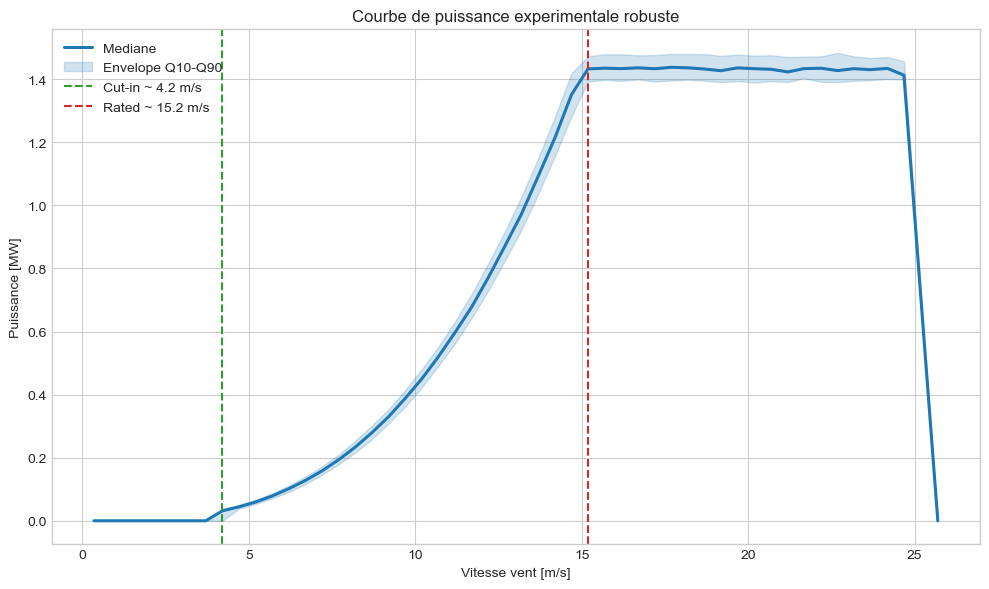

In [5]:
# Courbe de puissance experimentale robuste par classes de vitesse.
# Choix: mediane + quantiles pour reduire l'impact du bruit et des outliers.
bin_width = 0.5
vmax = np.ceil(df_on["wind_speed"].max())
bins = np.arange(0, vmax + bin_width, bin_width)

curve = (
    df_on.assign(speed_bin=pd.cut(df_on["wind_speed"], bins=bins, right=False))
    .groupby("speed_bin", observed=False)
    .agg(
        n=("power_w", "size"),
        v_mean=("wind_speed", "mean"),
        p_med=("power_w", "median"),
        p_q10=("power_w", lambda s: s.quantile(0.10)),
        p_q90=("power_w", lambda s: s.quantile(0.90)),
    )
    .reset_index(drop=True)
)

curve = curve[curve["n"] >= 20].copy()  # robustesse statistique minimale
p_rated = curve["p_med"].max()

# Detection automatique de vitesses caracteristiques.
cut_in_candidates = curve[curve["p_med"] > 0.01 * p_rated]
v_cut_in = cut_in_candidates["v_mean"].iloc[0] if not cut_in_candidates.empty else np.nan

rated_candidates = curve[curve["p_med"] > 0.95 * p_rated]
v_rated = rated_candidates["v_mean"].iloc[0] if not rated_candidates.empty else np.nan

print(f"Puissance nominale estimee (mediane): {p_rated/1e6:.3f} MW")
print(f"Vitesse de demarrage estimee: {v_cut_in:.2f} m/s")
print(f"Vitesse de regime nominal estimee: {v_rated:.2f} m/s")

display(curve.head(12))

plt.figure(figsize=(10, 6))
plt.plot(curve["v_mean"], curve["p_med"] / 1e6, color="#1f77b4", lw=2.2, label="Mediane")
plt.fill_between(
    curve["v_mean"],
    curve["p_q10"] / 1e6,
    curve["p_q90"] / 1e6,
    color="#1f77b4",
    alpha=0.20,
    label="Envelope Q10-Q90",
)
if not np.isnan(v_cut_in):
    plt.axvline(v_cut_in, color="#2ca02c", ls="--", lw=1.5, label=f"Cut-in ~ {v_cut_in:.1f} m/s")
if not np.isnan(v_rated):
    plt.axvline(v_rated, color="#d62728", ls="--", lw=1.5, label=f"Rated ~ {v_rated:.1f} m/s")

plt.title("Courbe de puissance experimentale robuste")
plt.xlabel("Vitesse vent [m/s]")
plt.ylabel("Puissance [MW]")
plt.legend()
plt.tight_layout()
plt.show()

Weibull estimee: k=1.853, c=9.884 m/s


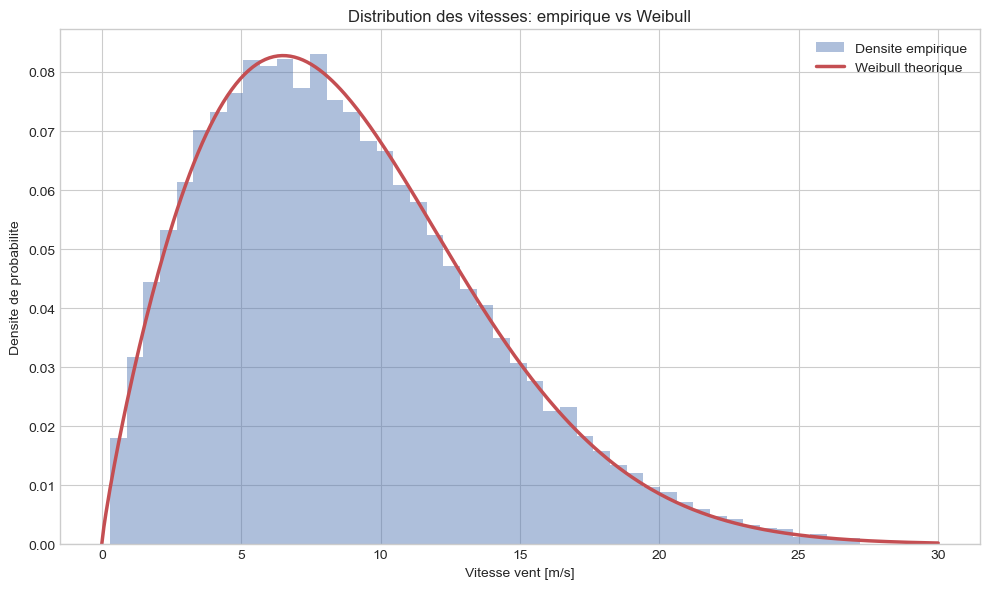

In [6]:
# Modelisation statistique du vent: ajustement Weibull par methode des moments.
# Cette forme est explicitement attendue dans les consignes pedagogiques.
v = df_on["wind_speed"].dropna()
mu = v.mean()
sigma = v.std(ddof=1)

# Approximation classique pour le parametre de forme k.
k = (sigma / mu) ** (-1.086)
# Parametre d'echelle c.
c = mu / math.gamma(1 + 1 / k)

print(f"Weibull estimee: k={k:.3f}, c={c:.3f} m/s")

# Densite theorique Weibull sur un maillage vitesse.
v_grid = np.linspace(0, max(30, float(v.max() + 2)), 400)
weibull_pdf = (k / c) * (v_grid / c) ** (k - 1) * np.exp(- (v_grid / c) ** k)

plt.figure(figsize=(10, 6))
plt.hist(v, bins=45, density=True, alpha=0.45, color="#4C72B0", label="Densite empirique")
plt.plot(v_grid, weibull_pdf, color="#C44E52", lw=2.5, label="Weibull theorique")
plt.title("Distribution des vitesses: empirique vs Weibull")
plt.xlabel("Vitesse vent [m/s]")
plt.ylabel("Densite de probabilite")
plt.legend()
plt.tight_layout()
plt.show()

Top 10 conditions d'exploitation (vitesse-direction):


,speed_bin,dir_sector,n,availability,p_med,score
203,"[15, 16)",240,19,1.000,"1,454,795.000",0.999
230,"[17, 18)",270,24,1.000,"1,456,829.000",0.999
235,"[18, 19)",30,36,1.000,"1,453,643.000",0.998
232,"[17, 18)",330,27,1.000,"1,450,319.000",0.998
236,"[18, 19)",60,26,1.000,"1,450,315.000",0.998
244,"[18, 19)",300,29,1.000,"1,447,444.000",0.997
208,"[16, 17)",0,47,1.000,"1,446,884.000",0.997
231,"[17, 18)",300,29,1.000,"1,445,140.000",0.997
260,"[20, 21)",0,19,1.000,"1,442,668.000",0.996
202,"[15, 16)",210,27,1.000,"1,440,520.000",0.996


C:\Users\loupa\AppData\Local\Temp\ipykernel_18720\2950610807.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heat = operating_map.pivot_table(


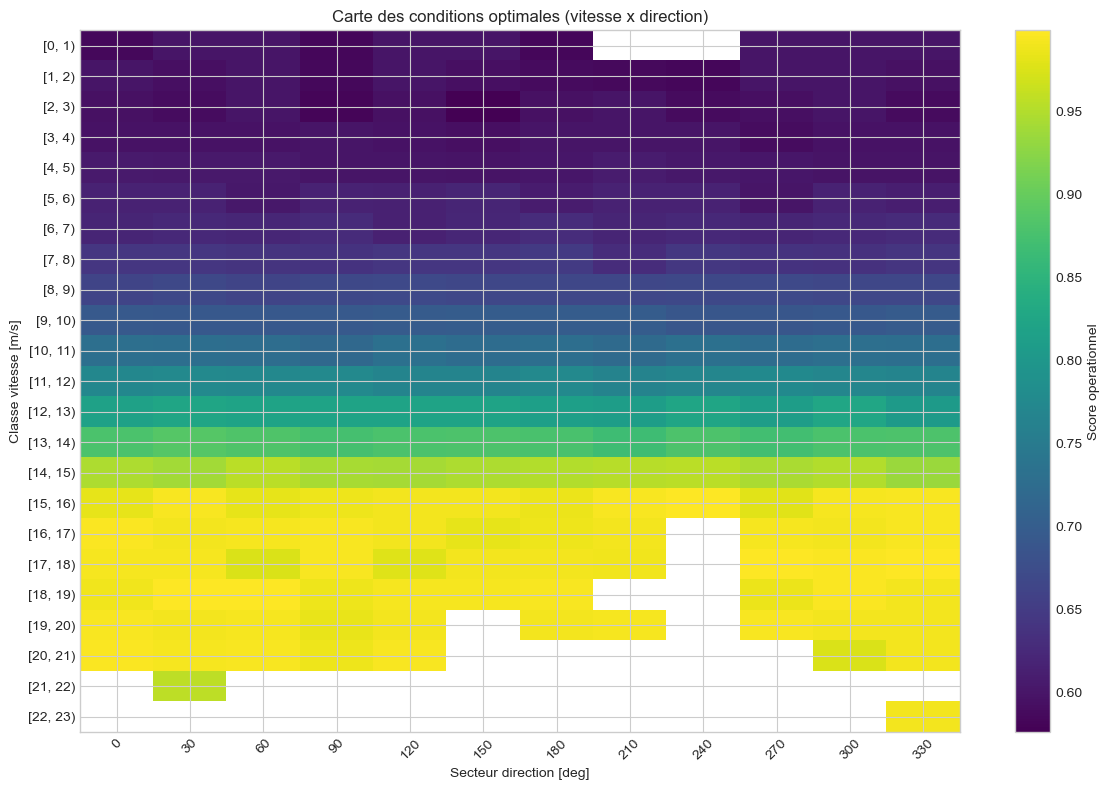

In [7]:
# Conditions optimales d'exploitation: combinaison vitesse-direction.
# Construction de secteurs angulaires et d'un score multicritere interpretable.
df_map = df.copy()
df_map["dir_sector"] = (np.floor(df_map["wind_dir"] / 30) * 30).astype("Int64")
df_map["speed_bin"] = pd.cut(df_map["wind_speed"], bins=np.arange(0, 31, 1), right=False)

operating_map = (
    df_map.groupby(["speed_bin", "dir_sector"], observed=False)
    .agg(
        n=("power_w", "size"),
        availability=("status", "mean"),
        p_med=("power_w", "median"),
        p_mean=("power_w", "mean"),
    )
    .reset_index()
)

# Regularisation simple: ignorer les classes trop peu representees.
operating_map = operating_map[operating_map["n"] >= 15].copy()

# Score de performance operationnelle (0-1) base sur 3 dimensions:
# 1) disponibilite, 2) puissance mediane, 3) stabilite (ecart med/mean).
p_scale = operating_map["p_med"].max() if len(operating_map) else 1.0
stability = 1 - (operating_map["p_mean"] - operating_map["p_med"]).abs() / (operating_map["p_mean"].abs() + 1)
operating_map["score"] = (
    0.45 * operating_map["availability"]
    + 0.40 * (operating_map["p_med"] / p_scale)
    + 0.15 * stability.clip(lower=0, upper=1)
)

best_conditions = operating_map.sort_values("score", ascending=False).head(10).copy()
print("Top 10 conditions d'exploitation (vitesse-direction):")
display(best_conditions[["speed_bin", "dir_sector", "n", "availability", "p_med", "score"]])

# Visualisation carte de chaleur score par vitesse-direction.
heat = operating_map.pivot_table(
    index="speed_bin",
    columns="dir_sector",
    values="score",
    aggfunc="mean"
)

plt.figure(figsize=(12, 8))
plt.imshow(heat, aspect="auto", cmap="viridis", interpolation="nearest")
plt.colorbar(label="Score operationnel")
plt.title("Carte des conditions optimales (vitesse x direction)")
plt.xlabel("Secteur direction [deg]")
plt.ylabel("Classe vitesse [m/s]")
plt.xticks(ticks=np.arange(len(heat.columns)), labels=[str(c) for c in heat.columns], rotation=45)
plt.yticks(ticks=np.arange(len(heat.index)), labels=[str(i) for i in heat.index])
plt.tight_layout()
plt.show()

In [8]:
# Indicateurs de synthese reutilisables tels quels dans le rapport / slides.
p_rated_obs = df_on["power_w"].quantile(0.995)
p_mean_obs = df_on["power_w"].mean()
capacity_factor_obs = p_mean_obs / p_rated_obs

# Regime de vent favorable selon la courbe robuste.
if len(curve) > 0:
    top_curve = curve.sort_values("p_med", ascending=False).head(5)
    v_opt_low = top_curve["v_mean"].min()
    v_opt_high = top_curve["v_mean"].max()
else:
    v_opt_low, v_opt_high = np.nan, np.nan

summary = pd.Series(
    {
        "Nombre de mesures": len(df),
        "Disponibilite machine": availability,
        "Vitesse moyenne (status=1) [m/s]": df_on["wind_speed"].mean(),
        "Direction moyenne (circulaire approx.) [deg]": df_on["wind_dir"].mean(),
        "Puissance moyenne (status=1) [MW]": p_mean_obs / 1e6,
        "Puissance quasi nominale P99.5 [MW]": p_rated_obs / 1e6,
        "Facteur de charge observe": capacity_factor_obs,
        "Zone de vent la plus productive [m/s]": f"{v_opt_low:.1f} - {v_opt_high:.1f}",
        "Parametre Weibull k": k,
        "Parametre Weibull c [m/s]": c,
    },
    name="Valeur"
)

display(summary.to_frame())

# Conclusion technique courte (format bloc reutilisable dans une diapo).
print("\nConclusion technique:")
print("- La puissance suit une loi croissante proche de V^3 jusqu'au plateau nominal.")
print("- La disponibilite operationnelle est un critere aussi important que la vitesse.")
print("- La carte vitesse-direction fournit un outil de decision rapide pour l'implantation.")

,Valeur
Nombre de mesures,19918
Disponibilite machine,0.991
Vitesse moyenne (status=1) [m/s],8.779
Direction moyenne (circulaire approx.) [deg],171.439
Puissance moyenne (status=1) [MW],0.439
Puissance quasi nominale P99.5 [MW],1.486
Facteur de charge observe,0.295
Zone de vent la plus productive [m/s],15.7 - 19.7
Parametre Weibull k,1.853
Parametre Weibull c [m/s],9.884



Conclusion technique:
- La puissance suit une loi croissante proche de V^3 jusqu'au plateau nominal.
- La disponibilite operationnelle est un critere aussi important que la vitesse.
- La carte vitesse-direction fournit un outil de decision rapide pour l'implantation.
